# CARGA DE LIBRERÍAS

In [74]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

# Lectura del csv de resultados

In [75]:
from pathlib import Path

METRICS_PATH = (
    Path("..")
    / "results"
    / "yolo"
    / "test"
    / "yolo_test_metrics.csv"
)

df = pd.read_csv(METRICS_PATH)

df = df.drop(columns = 'model_path')

df

,dataset,image_size,model,test_type,precision,recall,mAP50,mAP50-95
0,dataset_v1,640,yolo26n,diurn,0.870428,0.776961,0.859031,0.586492
1,dataset_v1,640,yolo26n,nocturn,0.864702,0.835567,0.885714,0.412205
2,dataset_v1,640,yolo26s,diurn,0.911786,0.886668,0.937384,0.635447
3,dataset_v1,640,yolo26s,nocturn,0.897980,0.821269,0.893694,0.465589
4,dataset_v1,800,yolo26n,diurn,0.926880,0.822304,0.917841,0.616979
5,dataset_v1,800,yolo26n,nocturn,0.885998,0.806077,0.881019,0.440745
6,dataset_v1,800,yolo26s,diurn,0.926683,0.913879,0.949691,0.728692
7,dataset_v1,800,yolo26s,nocturn,0.909912,0.875533,0.927111,0.592470
8,dataset_v1,960,yolo26n,diurn,0.911698,0.847748,0.937099,0.684078
9,dataset_v1,960,yolo26n,nocturn,0.900831,0.848972,0.908248,0.509758


# Métricas originales

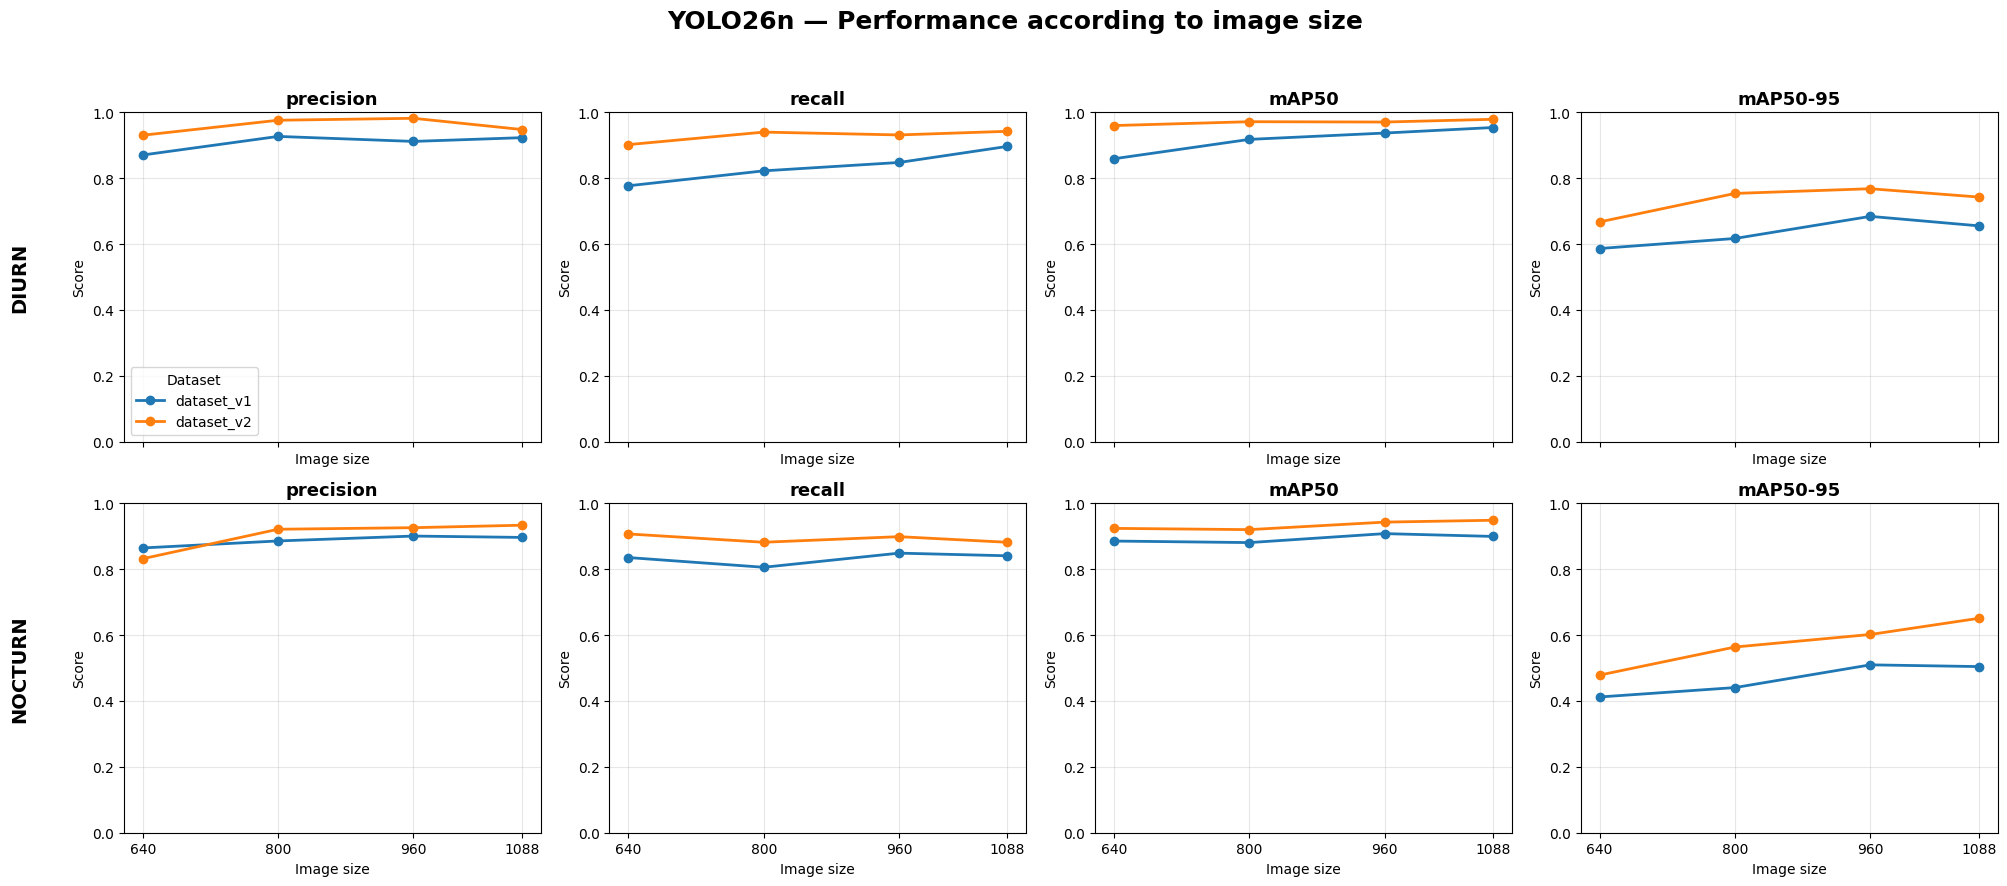

In [76]:
model_name = "yolo26n"

df_model = df[
    df["model"] == model_name
].copy()

df_model = df_model.sort_values(
    ["test_type", "dataset", "image_size"]
)


metrics = [
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
]

test_types = [
    "diurn",
    "nocturn",
]

datasets = [
    "dataset_v1",
    "dataset_v2",
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(20, 9),
    sharex=True,
)



# PLOT

for row, test_type in enumerate(test_types):

    df_test = df_model[
        df_model["test_type"] == test_type
    ]

    for col, metric in enumerate(metrics):

        ax = axes[row, col]

        for dataset in datasets:

            data = df_test[
                df_test["dataset"] == dataset
            ].sort_values("image_size")

            ax.plot(
                data["image_size"],
                data[metric],
                marker="o",
                linewidth=2,
                label=dataset,
            )

        ax.set_title(
            metric,
            fontsize=13,
            fontweight="bold",
        )

        ax.set_xlabel(
            "Image size"
        )

        ax.set_ylabel(
            "Score"
        )

        ax.set_xticks(
            [640, 800, 960, 1088]
        )

        ax.set_ylim(
            0,
            1
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        if col == 0:

            ax.text(
                -0.25,
                0.5,
                test_type.upper(),
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=14,
                fontweight="bold",
            )

        if row == 0 and col == 0:

            ax.legend(
                title="Dataset"
            )
            
            
            
fig.suptitle(
    "YOLO26n — Performance according to image size",
    fontsize=18,
    fontweight="bold",
)


plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

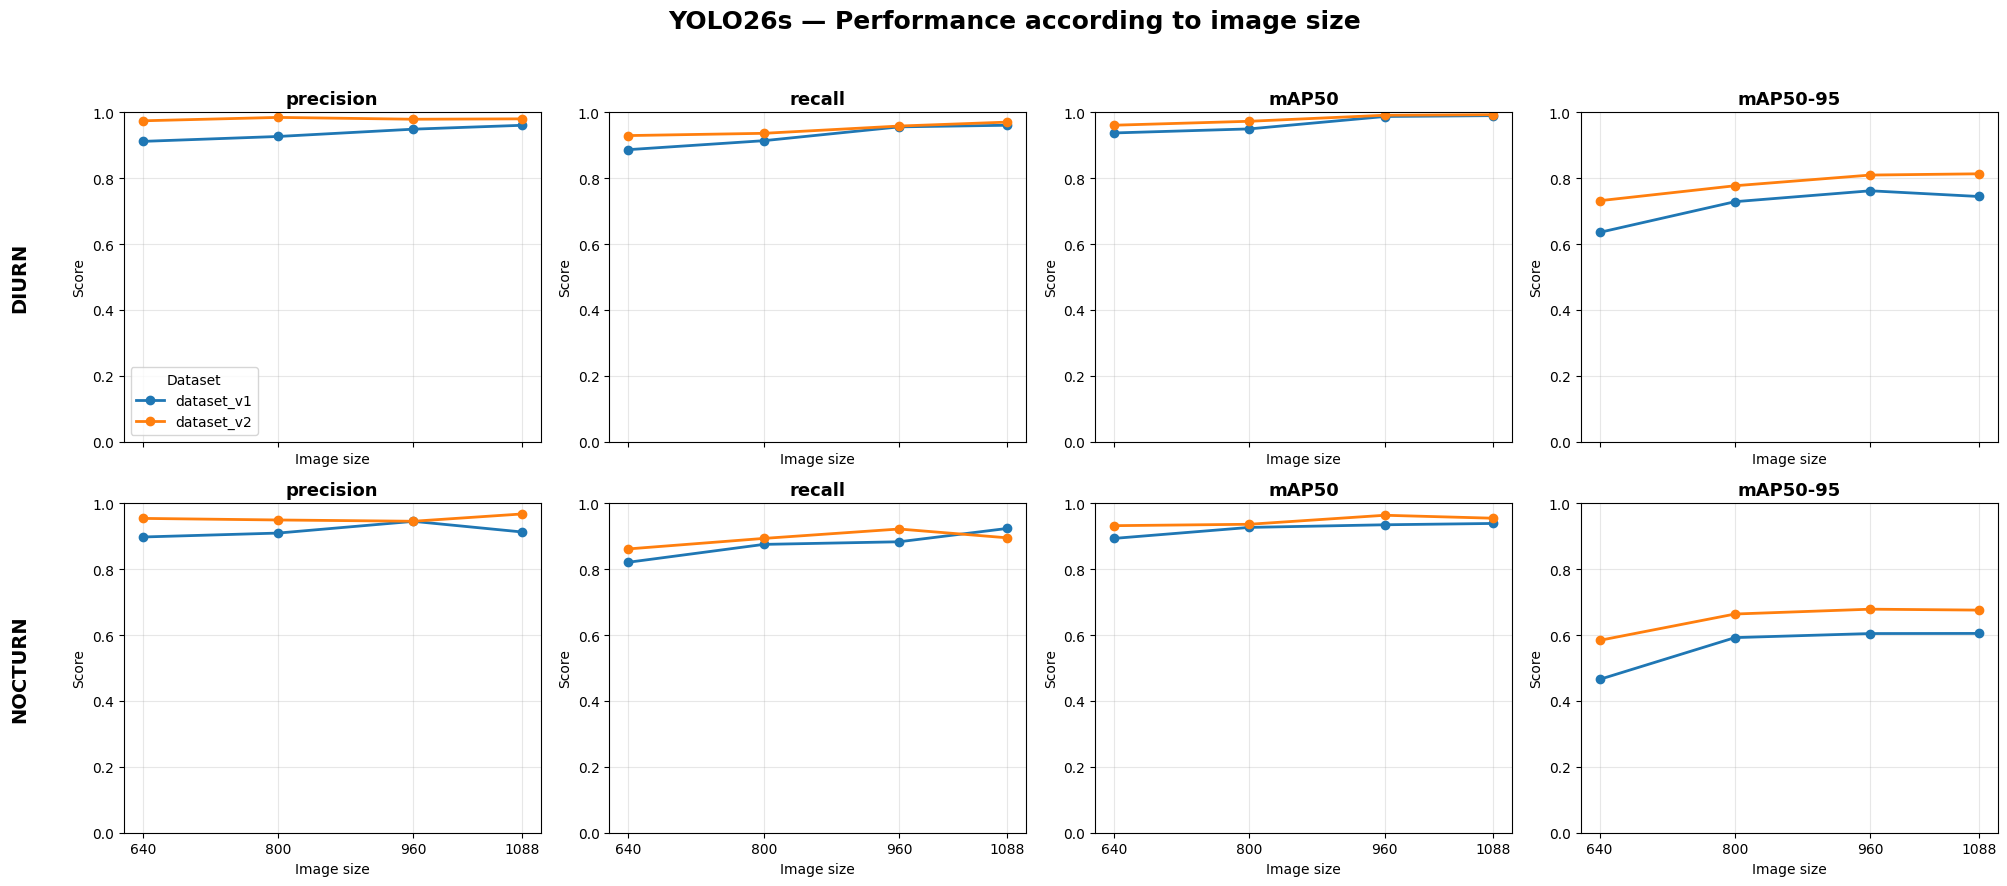

In [77]:
model_name = "yolo26s"

df_model = df[
    df["model"] == model_name
].copy()

df_model = df_model.sort_values(
    ["test_type", "dataset", "image_size"]
)


metrics = [
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
]

test_types = [
    "diurn",
    "nocturn",
]

datasets = [
    "dataset_v1",
    "dataset_v2",
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(20, 9),
    sharex=True,
)



# PLOT

for row, test_type in enumerate(test_types):

    df_test = df_model[
        df_model["test_type"] == test_type
    ]

    for col, metric in enumerate(metrics):

        ax = axes[row, col]

        for dataset in datasets:

            data = df_test[
                df_test["dataset"] == dataset
            ].sort_values("image_size")

            ax.plot(
                data["image_size"],
                data[metric],
                marker="o",
                linewidth=2,
                label=dataset,
            )

        ax.set_title(
            metric,
            fontsize=13,
            fontweight="bold",
        )

        ax.set_xlabel(
            "Image size"
        )

        ax.set_ylabel(
            "Score"
        )

        ax.set_xticks(
            [640, 800, 960, 1088]
        )

        ax.set_ylim(
            0,
            1
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        if col == 0:

            ax.text(
                -0.25,
                0.5,
                test_type.upper(),
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=14,
                fontweight="bold",
            )

        if row == 0 and col == 0:

            ax.legend(
                title="Dataset"
            )
            
            
            
fig.suptitle(
    "YOLO26s — Performance according to image size",
    fontsize=18,
    fontweight="bold",
)


plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

# Análisis Dataset V2

Filtramos df para solo incluir dataset_v2 dado que gana en todas las métricas.

In [84]:
df = df[df['dataset']== 'dataset_v2']

df

,dataset,image_size,model,test_type,precision,recall,mAP50,mAP50-95
16,dataset_v2,640,yolo26n,diurn,0.930455,0.901961,0.959866,0.667257
17,dataset_v2,640,yolo26n,nocturn,0.831999,0.907269,0.924191,0.478686
18,dataset_v2,640,yolo26s,diurn,0.974307,0.929421,0.960872,0.731628
19,dataset_v2,640,yolo26s,nocturn,0.954470,0.861777,0.932359,0.584125
20,dataset_v2,800,yolo26n,diurn,0.975984,0.939951,0.971544,0.753743
21,dataset_v2,800,yolo26n,nocturn,0.921535,0.882038,0.920369,0.563899
22,dataset_v2,800,yolo26s,diurn,0.984599,0.936275,0.972856,0.777079
23,dataset_v2,800,yolo26s,nocturn,0.949668,0.893672,0.936637,0.664103
24,dataset_v2,960,yolo26n,diurn,0.981926,0.931373,0.970528,0.768034
25,dataset_v2,960,yolo26n,nocturn,0.926261,0.899017,0.943178,0.601983


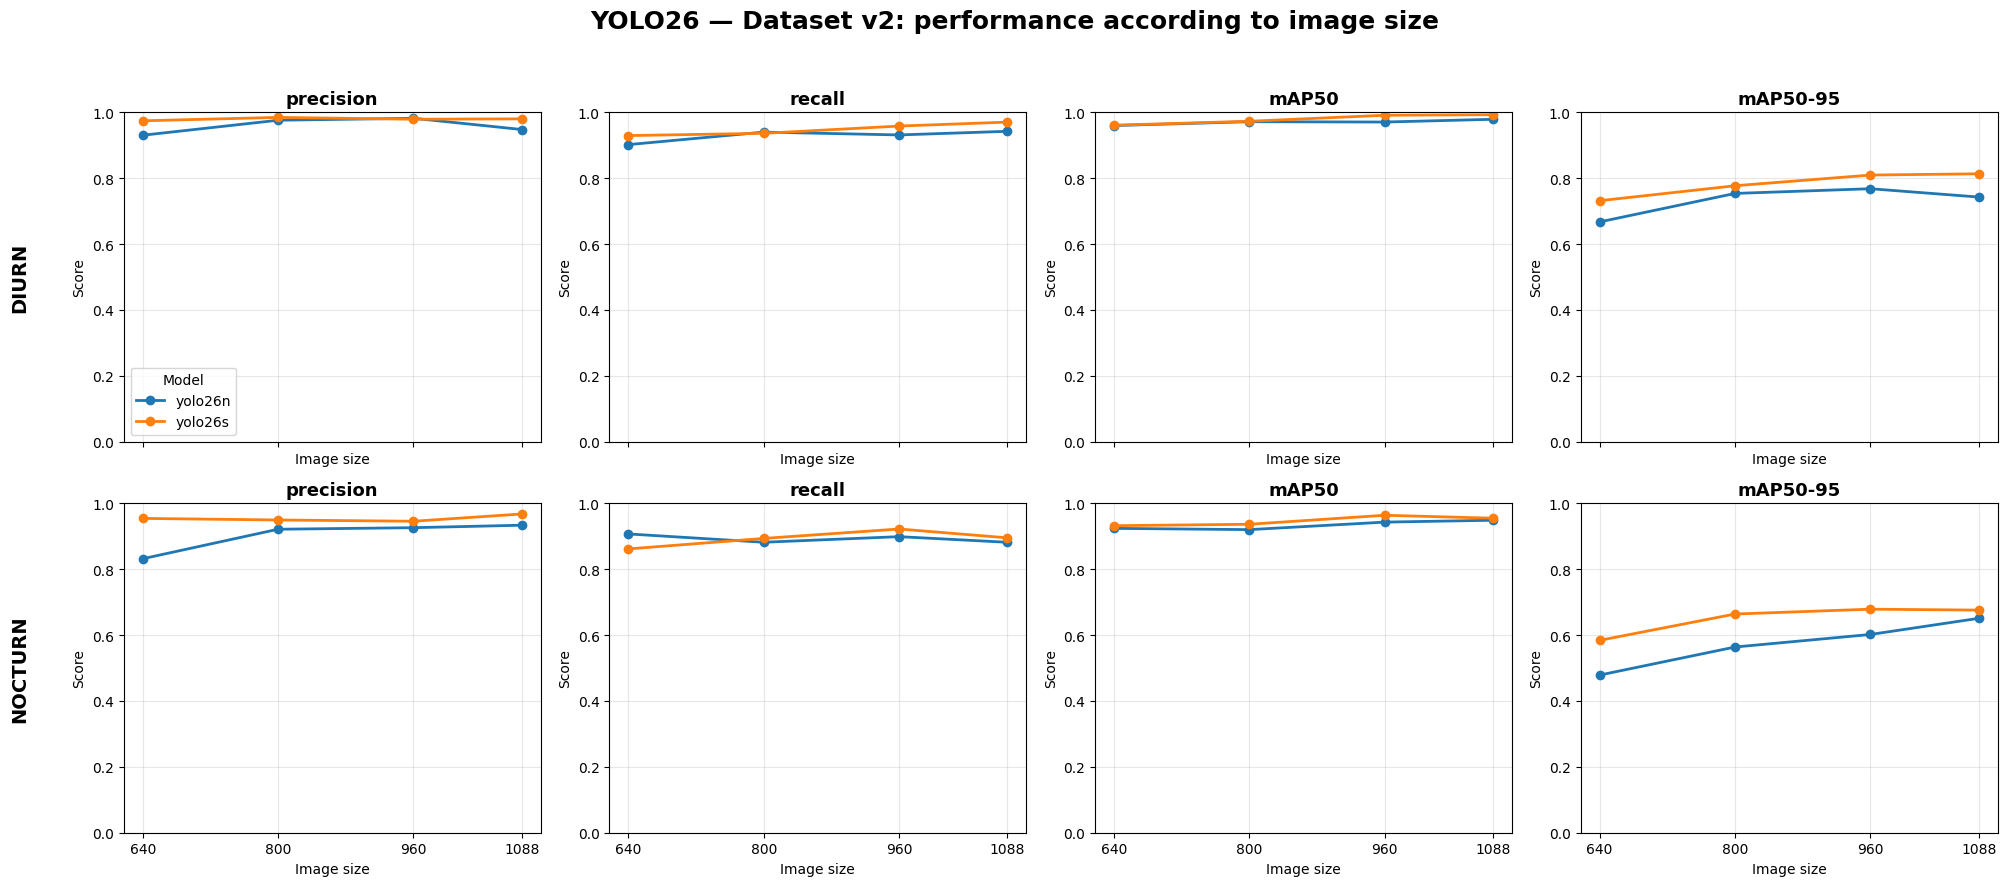

In [85]:
metrics = [
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
]

test_types = [
    "diurn",
    "nocturn",
]

models = [
    "yolo26n",
    "yolo26s",
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(20, 9),
    sharex=True,
)

for row, test_type in enumerate(test_types):

    df_test = df[
        df["test_type"] == test_type
    ]

    for col, metric in enumerate(metrics):

        ax = axes[row, col]

        for model in models:

            data = df_test[
                df_test["model"] == model
            ].sort_values("image_size")

            ax.plot(
                data["image_size"],
                data[metric],
                marker="o",
                linewidth=2,
                label=model,
            )

        ax.set_title(
            metric,
            fontsize=13,
            fontweight="bold",
        )

        ax.set_xlabel(
            "Image size"
        )

        ax.set_ylabel(
            "Score"
        )

        ax.set_xticks(
            [640, 800, 960, 1088]
        )

        ax.set_ylim(
            0,
            1
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        if col == 0:

            ax.text(
                -0.25,
                0.5,
                test_type.upper(),
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=14,
                fontweight="bold",
            )

        if row == 0 and col == 0:

            ax.legend(
                title="Model"
            )
            
fig.suptitle(
    "YOLO26 — Dataset v2: performance according to image size",
    fontsize=18,
    fontweight="bold",
)


plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

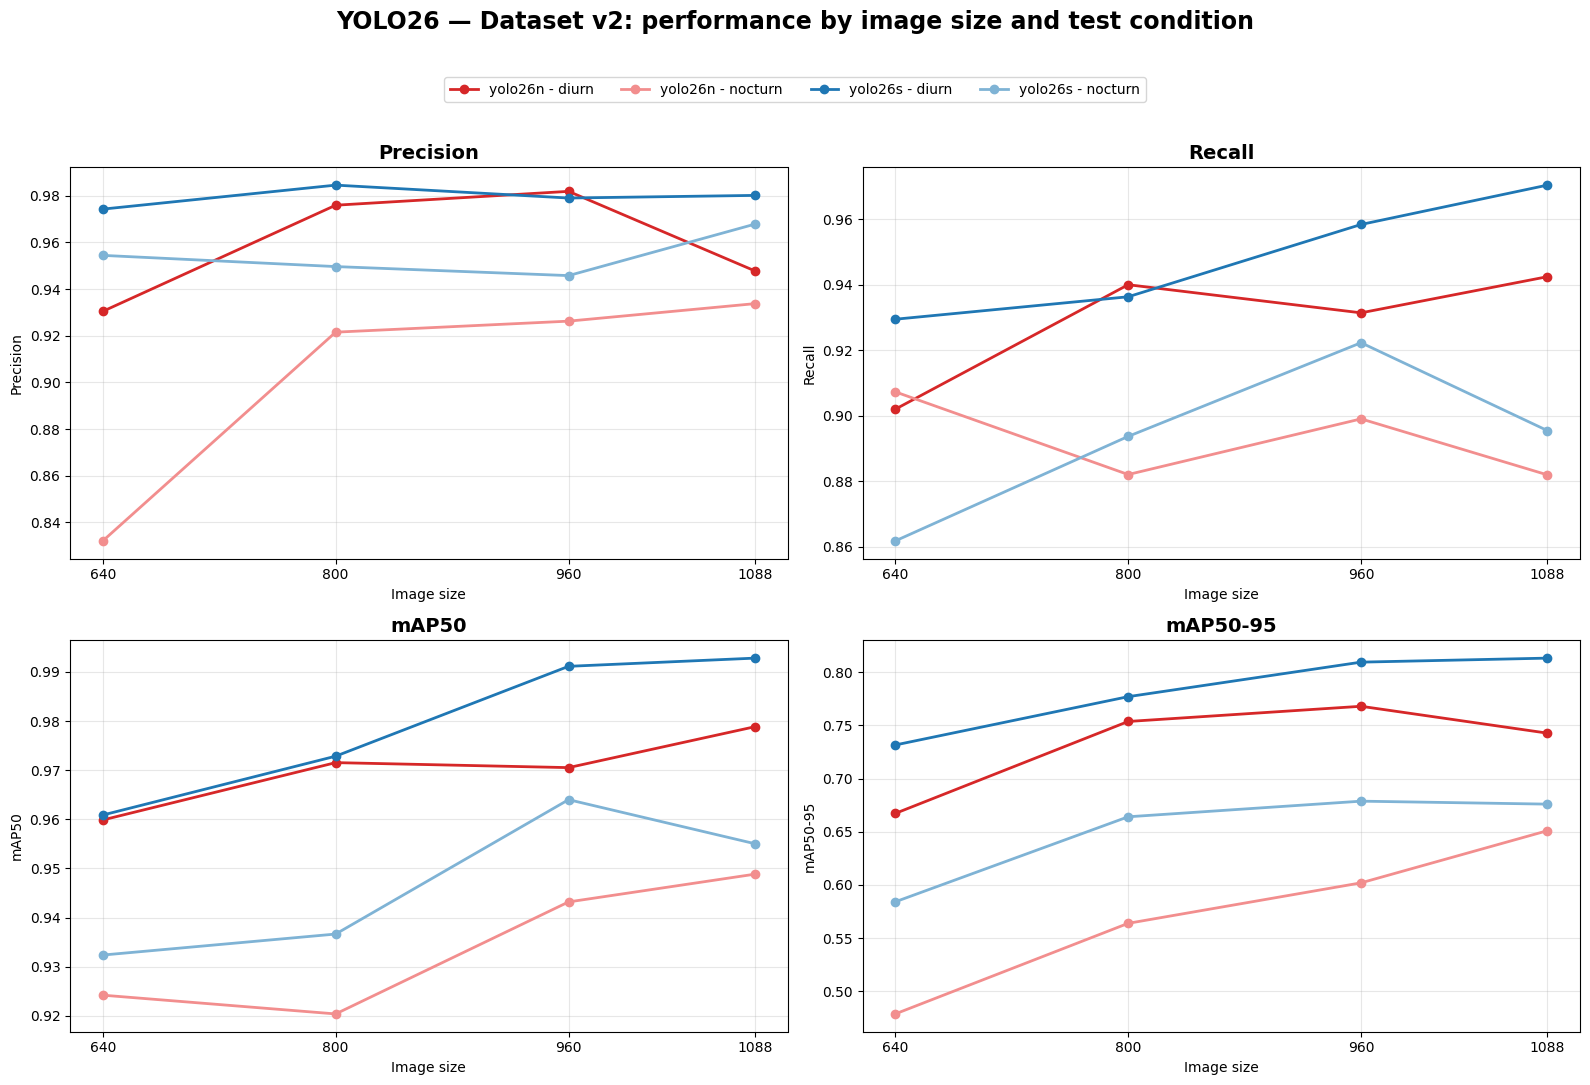

In [86]:
# ============================================================
# MÉTRICAS ORIGINALES
# ============================================================

metrics = {
    "precision": "Precision",
    "recall": "Recall",
    "mAP50": "mAP50",
    "mAP50-95": "mAP50-95",
}


# ============================================================
# COLORES
# ============================================================

colors = {
    "yolo26n": {
        "diurn": "#D62728",
        "nocturn": "#F28E8E",
    },
    "yolo26s": {
        "diurn": "#1F77B4",
        "nocturn": "#7FB3D5",
    },
}


# ============================================================
# FIGURA
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10),
)

axes = axes.flatten()


# ============================================================
# GRÁFICOS
# ============================================================

for ax, (metric, title) in zip(
    axes,
    metrics.items(),
):

    for model in ["yolo26n", "yolo26s"]:

        for test_type in ["diurn", "nocturn"]:

            data = df_pivot[
                df_pivot["model"] == model
            ].sort_values("image_size")

            column = (
                f"{test_type}_{metric}"
            )

            ax.plot(
                data["image_size"],
                data[column],
                marker="o",
                linewidth=2,
                color=colors[model][test_type],
                label=f"{model} - {test_type}",
            )

    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
    )

    # --------------------------------------------------------
    # Ejes
    # --------------------------------------------------------

    ax.set_xlabel(
        "Image size"
    )

    ax.set_ylabel(
        title
    )

    ax.set_xticks(
        [640, 800, 960, 1088]
    )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        True,
        alpha=0.3,
    )


# ============================================================
# LEYENDA
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.02),
)


# ============================================================
# TÍTULO GENERAL
# ============================================================

fig.suptitle(
    "YOLO26 — Dataset v2: performance by image size and test condition",
    fontsize=17,
    fontweight="bold",
    y=1.08,
)

plt.tight_layout()

plt.show()

# Análisis de métricas derivadas

Obtenemos la tabla en formato wide para sacar métricas derivadas

In [87]:
metrics = [
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
]

df_pivot = df.pivot(
    index=[
        "dataset",
        "image_size",
        "model",
    ],
    columns="test_type",
    values=metrics,
)


df_pivot = df_pivot[
    [
        (metric, test_type)
        for test_type in ["diurn", "nocturn"]
        for metric in metrics
    ]
]


df_pivot.columns = [
    f"{test_type}_{metric}"
    for metric, test_type in df_pivot.columns
]

df_pivot = df_pivot.reset_index()

df_pivot

,dataset,image_size,model,diurn_precision,diurn_recall,diurn_mAP50,diurn_mAP50-95,nocturn_precision,nocturn_recall,nocturn_mAP50,nocturn_mAP50-95
0,dataset_v2,640,yolo26n,0.930455,0.901961,0.959866,0.667257,0.831999,0.907269,0.924191,0.478686
1,dataset_v2,640,yolo26s,0.974307,0.929421,0.960872,0.731628,0.954470,0.861777,0.932359,0.584125
2,dataset_v2,800,yolo26n,0.975984,0.939951,0.971544,0.753743,0.921535,0.882038,0.920369,0.563899
3,dataset_v2,800,yolo26s,0.984599,0.936275,0.972856,0.777079,0.949668,0.893672,0.936637,0.664103
4,dataset_v2,960,yolo26n,0.981926,0.931373,0.970528,0.768034,0.926261,0.899017,0.943178,0.601983
5,dataset_v2,960,yolo26s,0.979066,0.958333,0.991155,0.809550,0.945795,0.922252,0.964002,0.678797
6,dataset_v2,1088,yolo26n,0.947815,0.942402,0.978857,0.742772,0.933768,0.881936,0.948831,0.651019
7,dataset_v2,1088,yolo26s,0.980193,0.970340,0.992826,0.813327,0.967868,0.895442,0.955033,0.676005


Sacamos métricas derivadas para contrastar la diferencia de rendimiento dia vs noche.

- Pérdida absoluta nocturna: cuánto baja la métrica en términos de puntos.

- Pérdida relativa nocturna: cuál es el porcentaje del rendimiento que se pierde en la noche

- Ratio nocturno/diurno: qué proporcion del rendimiento diurno conserva el modelo.

In [88]:
# ============================================================
# MÉTRICAS DERIVADAS - PÉRDIDA NOCTURNA
# ============================================================

metrics = [
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
]

for metric in metrics:

    diurn_col = f"diurn_{metric}"
    nocturn_col = f"nocturn_{metric}"

    # --------------------------------------------------------
    # Pérdida absoluta
    # --------------------------------------------------------

    df_pivot[f"{metric}_loss_abs"] = (
        df_pivot[diurn_col]
        - df_pivot[nocturn_col]
    )

    # --------------------------------------------------------
    # Pérdida relativa (%)
    # --------------------------------------------------------

    df_pivot[f"{metric}_loss_pct"] = (
        (
            df_pivot[diurn_col]
            - df_pivot[nocturn_col]
        )
        / df_pivot[diurn_col]
    ) * 100

    # --------------------------------------------------------
    # Ratio nocturno / diurno
    # --------------------------------------------------------

    df_pivot[f"{metric}_night_ratio"] = (
        df_pivot[nocturn_col]
        / df_pivot[diurn_col]
    )


df_pivot

,dataset,image_size,model,diurn_precision,diurn_recall,diurn_mAP50,diurn_mAP50-95,nocturn_precision,nocturn_recall,nocturn_mAP50,nocturn_mAP50-95,precision_loss_abs,precision_loss_pct,precision_night_ratio,recall_loss_abs,recall_loss_pct,recall_night_ratio,mAP50_loss_abs,mAP50_loss_pct,mAP50_night_ratio,mAP50-95_loss_abs,mAP50-95_loss_pct,mAP50-95_night_ratio
0,dataset_v2,640,yolo26n,0.930455,0.901961,0.959866,0.667257,0.831999,0.907269,0.924191,0.478686,0.098456,10.581456,0.894185,-0.005308,-0.588480,1.005885,0.035675,3.716691,0.962833,0.188571,28.260592,0.717394
1,dataset_v2,640,yolo26s,0.974307,0.929421,0.960872,0.731628,0.954470,0.861777,0.932359,0.584125,0.019836,2.035936,0.979641,0.067644,7.278054,0.927219,0.028513,2.967459,0.970325,0.147503,20.160913,0.798391
2,dataset_v2,800,yolo26n,0.975984,0.939951,0.971544,0.753743,0.921535,0.882038,0.920369,0.563899,0.054449,5.578881,0.944211,0.057913,6.161326,0.938387,0.051175,5.267417,0.947326,0.189844,25.186827,0.748132
3,dataset_v2,800,yolo26s,0.984599,0.936275,0.972856,0.777079,0.949668,0.893672,0.936637,0.664103,0.034931,3.547710,0.964523,0.042603,4.550268,0.954497,0.036219,3.722949,0.962771,0.112976,14.538610,0.854614
4,dataset_v2,960,yolo26n,0.981926,0.931373,0.970528,0.768034,0.926261,0.899017,0.943178,0.601983,0.055665,5.668942,0.943311,0.032356,3.473966,0.965260,0.027351,2.818120,0.971819,0.166051,21.620220,0.783798
5,dataset_v2,960,yolo26s,0.979066,0.958333,0.991155,0.809550,0.945795,0.922252,0.964002,0.678797,0.033270,3.398187,0.966018,0.036081,3.765008,0.962350,0.027154,2.739615,0.972604,0.130754,16.151383,0.838486
6,dataset_v2,1088,yolo26n,0.947815,0.942402,0.978857,0.742772,0.933768,0.881936,0.948831,0.651019,0.014047,1.482057,0.985179,0.060466,6.416206,0.935838,0.030027,3.067539,0.969325,0.091753,12.352760,0.876472
7,dataset_v2,1088,yolo26s,0.980193,0.970340,0.992826,0.813327,0.967868,0.895442,0.955033,0.676005,0.012326,1.257457,0.987425,0.074897,7.718686,0.922813,0.037792,3.806538,0.961935,0.137322,16.884007,0.831160


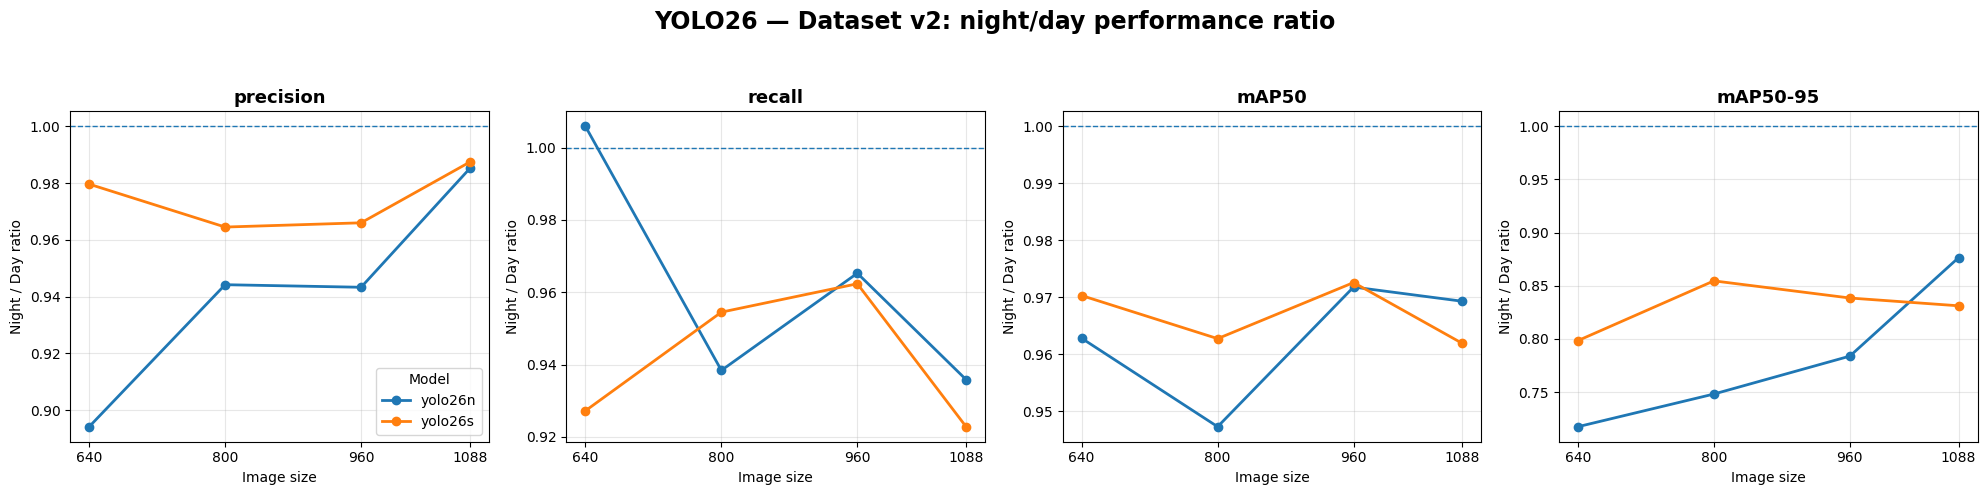

In [89]:
# ============================================================
# RATIO NOCTURNO / DIURNO
# ============================================================

metrics = [
    "precision_night_ratio",
    "recall_night_ratio",
    "mAP50_night_ratio",
    "mAP50-95_night_ratio",
]

models = [
    "yolo26n",
    "yolo26s",
]


# ============================================================
# FIGURA
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(20, 5),
    sharex=True,
)


# ============================================================
# GRÁFICOS
# ============================================================

for col, metric in enumerate(metrics):

    ax = axes[col]

    for model in models:

        data = df_pivot[
            df_pivot["model"] == model
        ].sort_values("image_size")

        ax.plot(
            data["image_size"],
            data[metric],
            marker="o",
            linewidth=2,
            label=model,
        )

    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------

    metric_name = metric.replace(
        "_night_ratio",
        "",
    )

    ax.set_title(
        metric_name,
        fontsize=13,
        fontweight="bold",
    )

    # --------------------------------------------------------
    # Ejes
    # --------------------------------------------------------

    ax.set_xlabel(
        "Image size"
    )

    ax.set_ylabel(
        "Night / Day ratio"
    )

    ax.set_xticks(
        [640, 800, 960, 1088]
    )

    # --------------------------------------------------------
    # Línea de referencia
    # --------------------------------------------------------

    ax.axhline(
        y=1.0,
        linestyle="--",
        linewidth=1,
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    # --------------------------------------------------------
    # Leyenda
    # --------------------------------------------------------

    if col == 0:

        ax.legend(
            title="Model"
        )


# ============================================================
# TÍTULO
# ============================================================

fig.suptitle(
    "YOLO26 — Dataset v2: night/day performance ratio",
    fontsize=17,
    fontweight="bold",
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.show()